# Week 6 Lab — Boosting Evolution: XGBoost vs LightGBM

## 실습 목표
1. **XGBoost**와 **LightGBM**의 baseline 성능을 비교한다.
2. `train / validation / test` 분할이 왜 중요한지 직접 확인한다.
3. **Early Stopping**을 적용해 과적합 제어 감각을 익힌다.
4. 핵심 파라미터(`learning_rate`, `n_estimators`, `max_depth`, `num_leaves`)를 간단히 비교한다.
5. Week06 HW03 / 과제 3에서 사용할 수 있는 실험 기록 형식을 익힌다.

---

## 오늘 실습 데이터
- 본 실습은 **Scikit-learn Breast Cancer Wisconsin** 데이터를 사용합니다.
- 이유:
  - 이진 분류 문제라 Accuracy / F1 / AUC 비교가 간단함
  - 행 수가 너무 크지 않아 40분 실습에 적합함
  - XGBoost / LightGBM 차이를 빠르게 체감할 수 있음

> 오늘 핵심은 **"어떤 라이브러리가 더 좋다"** 가 아니라  
> **"Boosting 모델은 validation과 stopping 전략까지 포함해서 설계해야 한다"** 입니다.


> **🗣️ [발표자 스크립트]**  
> "이번 실습은 6주차 이론에서 배운 부스팅 계열 모델을 직접 비교해보는 시간입니다.  
> 먼저 XGBoost와 LightGBM의 baseline을 확인하고, 그 다음 early stopping을 붙였을 때 validation 기준으로 어떤 차이가 생기는지 보겠습니다.  
> 마지막에는 아주 작은 파라미터 비교를 통해 점수가 아니라 실험 구조를 읽는 연습까지 연결하겠습니다."

## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`
- `xgboost`, `lightgbm`

### 설치 참고
- 로컬에서는 `uv` 기반 설치를 권장합니다.
- **macOS에서는 `xgboost`, `lightgbm` 모두 OpenMP 런타임(`libomp`)이 필요할 수 있습니다.**
- import 단계에서 `libomp.dylib` 에러가 나면 먼저 `brew install libomp`를 실행하세요.


In [ ]:
# 필요 패키지 설치 (최초 1회만)
# 로컬 uv 환경 예시
# !uv add pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

# Colab / 일반 Jupyter 환경 예시
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

# Mac 에서 xgboost / lightgbm import 에러가 나면 OpenMP 런타임이 없는 경우가 많습니다.
# 예: brew install libomp
# 설치 후에는 Jupyter Kernel을 완전히 재시작하세요.


## 1. 라이브러리 불러오기

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

try:
    import xgboost as xgb
except ImportError as e:
    raise ImportError("xgboost가 설치되어 있지 않습니다. 설치 셀을 먼저 확인하세요.") from e
except Exception as e:
    raise RuntimeError(
        "xgboost import 실패: macOS에서는 OpenMP 런타임(libomp)이 없으면 이 에러가 자주 발생합니다. "
        "터미널에서 `brew install libomp` 실행 후 Jupyter Kernel을 재시작한 뒤 다시 시도하세요. "
        f"원본 에러: {e}"
    ) from e

try:
    import lightgbm as lgb
except ImportError as e:
    raise ImportError("lightgbm이 설치되어 있지 않습니다. 설치 셀을 먼저 확인하세요.") from e
except Exception as e:
    raise RuntimeError(
        "lightgbm import 실패: macOS에서는 OpenMP 런타임(libomp)이 없으면 이 에러가 자주 발생합니다. "
        "터미널에서 `brew install libomp` 실행 후 Jupyter Kernel을 재시작한 뒤 다시 시도하세요. "
        f"원본 에러: {e}"
    ) from e

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


: 

## 2. 데이터 로드 및 기본 확인

In [2]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()

display(df.head())
print("shape:", df.shape)
print("target names:", cancer.target_names)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


shape: (569, 31)
target names: ['malignant' 'benign']


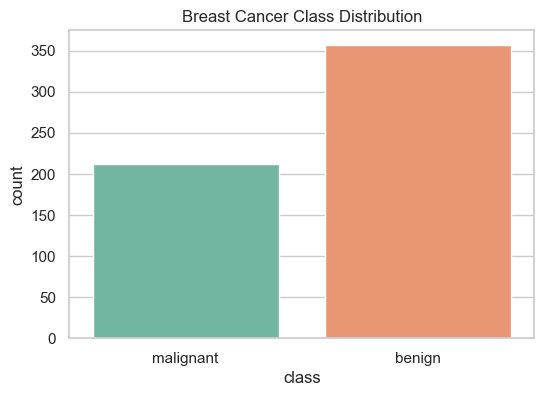

,count
target,
0,212
1,357


In [3]:
class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=[cancer.target_names[i] for i in class_counts.index], y=class_counts.values, palette="Set2")
plt.title("Breast Cancer Class Distribution")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

class_counts.to_frame("count")


## 3. Train / Validation / Test Split

- 이번 주는 **early stopping**이 핵심이므로 validation set이 반드시 필요합니다.
- 여기서는 `60% train / 20% validation / 20% test` 구조로 분리합니다.


In [4]:
X = df.drop(columns="target")
y = df["target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)


X_train: (341, 30)
X_valid: (114, 30)
X_test : (114, 30)


## 4. 평가 함수 정의

In [5]:
def evaluate_binary_classifier(model, X_train, X_valid, X_test, y_train, y_valid, y_test, model_name):
    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        test_prob = model.predict_proba(X_test)[:, 1]
    else:
        test_prob = None

    result = {
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "valid_accuracy": accuracy_score(y_valid, valid_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
    }
    if test_prob is not None:
        result["test_auc"] = roc_auc_score(y_test, test_prob)
    return result


## 5. Baseline 1 — XGBoost

- 먼저 상대적으로 보수적인 baseline 파라미터로 시작합니다.
- 아직 early stopping은 적용하지 않습니다.


In [6]:
xgb_baseline = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

xgb_baseline.fit(X_train, y_train)
result_xgb_baseline = evaluate_binary_classifier(
    xgb_baseline, X_train, X_valid, X_test, y_train, y_valid, y_test, "XGBoost baseline"
)
pd.DataFrame([result_xgb_baseline])


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc
0,XGBoost baseline,1.0,0.964912,0.938596,0.951724,0.992063


## 6. Baseline 2 — LightGBM

- LightGBM도 같은 감각의 baseline으로 비교합니다.
- `num_leaves`는 너무 공격적이지 않은 값으로 둡니다.


In [7]:
lgb_baseline = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgb_baseline.fit(X_train, y_train)
result_lgb_baseline = evaluate_binary_classifier(
    lgb_baseline, X_train, X_valid, X_test, y_train, y_valid, y_test, "LightGBM baseline"
)
pd.DataFrame([result_lgb_baseline])


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc
0,LightGBM baseline,1.0,0.964912,0.95614,0.965035,0.993386


In [8]:
baseline_results = pd.DataFrame([result_xgb_baseline, result_lgb_baseline])
baseline_results.style.format({
    "train_accuracy": "{:.3f}",
    "valid_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "test_f1": "{:.3f}",
    "test_auc": "{:.3f}",
})


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc
0,XGBoost baseline,1.000,0.965,0.939,0.952,0.992
1,LightGBM baseline,1.000,0.965,0.956,0.965,0.993


## 7. Early Stopping 적용 — XGBoost

- validation 성능이 더 이상 좋아지지 않으면 학습을 멈춥니다.
- 실제 실무에서는 이 방식이 과적합 방지에 매우 중요합니다.


In [9]:
xgb_es = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
)

xgb_es.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False,
)

result_xgb_es = evaluate_binary_classifier(
    xgb_es, X_train, X_valid, X_test, y_train, y_valid, y_test, "XGBoost + early stopping"
)
print("best_iteration:", getattr(xgb_es, "best_iteration", None))
pd.DataFrame([result_xgb_es])


best_iteration: 282


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc
0,XGBoost + early stopping,1.0,0.964912,0.938596,0.951049,0.992394


## 8. Early Stopping 적용 — LightGBM

In [10]:
lgb_es = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgb_es.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(0)],
)

result_lgb_es = evaluate_binary_classifier(
    lgb_es, X_train, X_valid, X_test, y_train, y_valid, y_test, "LightGBM + early stopping"
)
print("best_iteration_:", getattr(lgb_es, "best_iteration_", None))
pd.DataFrame([result_lgb_es])


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[136]	valid_0's binary_logloss: 0.122276
best_iteration_: 136


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc
0,LightGBM + early stopping,0.997067,0.964912,0.95614,0.965035,0.989418


In [11]:
es_results = pd.DataFrame([
    result_xgb_baseline,
    result_xgb_es,
    result_lgb_baseline,
    result_lgb_es,
])

es_results.style.format({
    "train_accuracy": "{:.3f}",
    "valid_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "test_f1": "{:.3f}",
    "test_auc": "{:.3f}",
})


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc
0,XGBoost baseline,1.000,0.965,0.939,0.952,0.992
1,XGBoost + early stopping,1.000,0.965,0.939,0.951,0.992
2,LightGBM baseline,1.000,0.965,0.956,0.965,0.993
3,LightGBM + early stopping,0.997,0.965,0.956,0.965,0.989


## 9. 간단한 파라미터 비교 실험

- 전체 Grid Search를 돌리기보다, 수업 시간에는 **작은 비교 실험**이 더 적절합니다.
- 여기서는 XGBoost 2개 설정, LightGBM 2개 설정만 비교합니다.


In [12]:
small_experiments = []

xgb_configs = [
    {"learning_rate": 0.05, "max_depth": 3, "n_estimators": 300},
    {"learning_rate": 0.03, "max_depth": 5, "n_estimators": 500},
]

for i, cfg in enumerate(xgb_configs, start=1):
    model = xgb.XGBClassifier(
        eval_metric="logloss",
        early_stopping_rounds=30,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        **cfg,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )
    result = evaluate_binary_classifier(
        model, X_train, X_valid, X_test, y_train, y_valid, y_test, f"XGB exp{i}"
    )
    result.update(cfg)
    small_experiments.append(result)

lgb_configs = [
    {"learning_rate": 0.05, "max_depth": 3, "num_leaves": 15, "n_estimators": 300},
    {"learning_rate": 0.03, "max_depth": 5, "num_leaves": 31, "n_estimators": 500},
]

for i, cfg in enumerate(lgb_configs, start=1):
    model = lgb.LGBMClassifier(
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbose=-1,
        **cfg,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(0)],
    )
    result = evaluate_binary_classifier(
        model, X_train, X_valid, X_test, y_train, y_valid, y_test, f"LGBM exp{i}"
    )
    result.update(cfg)
    small_experiments.append(result)

exp_df = pd.DataFrame(small_experiments)
exp_df.sort_values("test_auc", ascending=False).style.format({
    "train_accuracy": "{:.3f}",
    "valid_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "test_f1": "{:.3f}",
    "test_auc": "{:.3f}",
})


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[138]	valid_0's binary_logloss: 0.125683
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[125]	valid_0's binary_logloss: 0.128014


,model,train_accuracy,valid_accuracy,test_accuracy,test_f1,test_auc,learning_rate,max_depth,n_estimators,num_leaves
2,LGBM exp1,1.000,0.965,0.947,0.958,0.994,0.050000,3,300,15.000000
1,XGB exp2,1.000,0.965,0.939,0.951,0.993,0.030000,5,500,nan
0,XGB exp1,1.000,0.974,0.947,0.958,0.991,0.050000,3,300,nan
3,LGBM exp2,0.997,0.965,0.956,0.965,0.990,0.030000,5,500,31.000000


## 10. Feature Importance 간단 비교

- 이번 주 핵심은 해석보다는 성능과 validation 구조지만,
- 어떤 feature가 상위에 오는지 보는 것은 모델 감각을 잡는 데 도움이 됩니다.


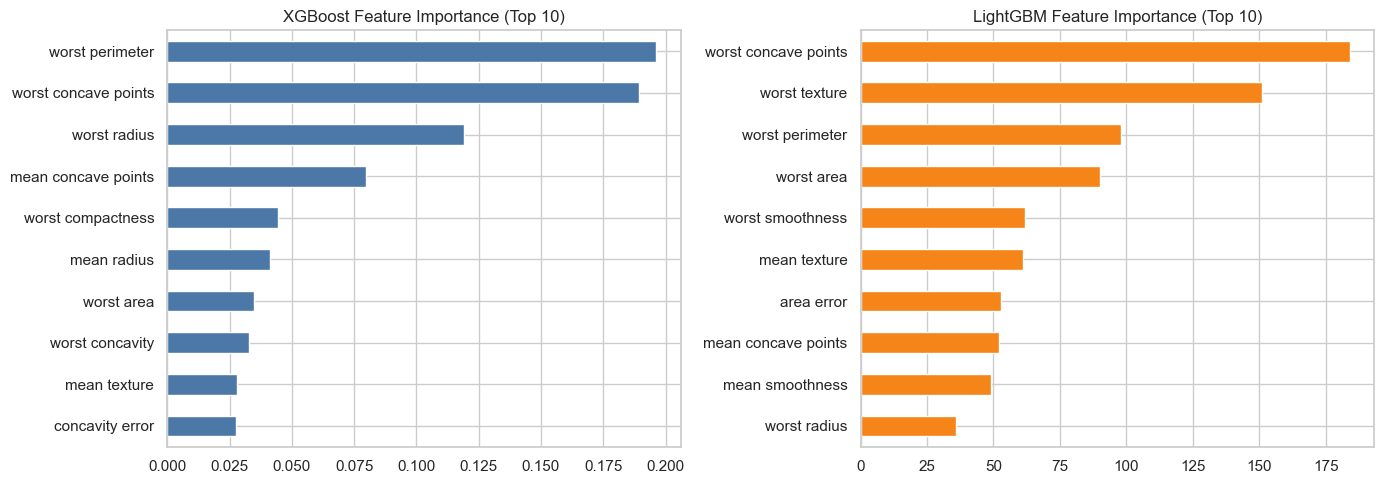

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xgb_importance = pd.Series(xgb_es.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
xgb_importance.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("XGBoost Feature Importance (Top 10)")

lgb_importance = pd.Series(lgb_es.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
lgb_importance.sort_values().plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title("LightGBM Feature Importance (Top 10)")

plt.tight_layout()
plt.show()


## 11. Confusion Matrix / Classification Report

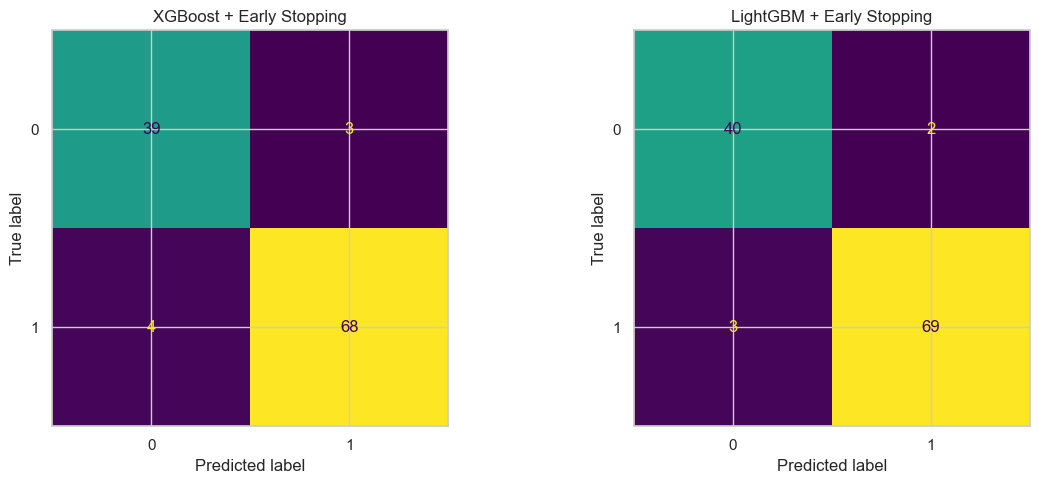

[XGBoost + Early Stopping]
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

[LightGBM + Early Stopping]
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(xgb_es, X_test, y_test, ax=axes[0], colorbar=False)
axes[0].set_title("XGBoost + Early Stopping")

ConfusionMatrixDisplay.from_estimator(lgb_es, X_test, y_test, ax=axes[1], colorbar=False)
axes[1].set_title("LightGBM + Early Stopping")

plt.tight_layout()
plt.show()

print("[XGBoost + Early Stopping]")
print(classification_report(y_test, xgb_es.predict(X_test), target_names=cancer.target_names))

print("[LightGBM + Early Stopping]")
print(classification_report(y_test, lgb_es.predict(X_test), target_names=cancer.target_names))


## 12. 실습 해석 가이드

### 확인할 포인트
1. baseline과 early stopping 적용 모델의 차이는 어떠했는가?
2. train 점수와 validation 점수 사이의 gap은 어땠는가?
3. XGBoost와 LightGBM 중 어떤 모델이 더 안정적으로 보였는가?
4. `learning_rate`, `n_estimators`, `max_depth`, `num_leaves` 변화가 어떤 방향으로 작용했는가?
5. 왜 leaderboard보다 validation 구조를 먼저 봐야 하는가?

### 한 줄 정리
- **Boosting 모델은 강력하지만, validation과 early stopping이 함께 설계되어야 한다.**


## 13. Week06 HW03 / 과제 3 연결

- 이번 실습 결과를 바탕으로 다음 항목을 정리해보면 과제에 바로 도움이 됩니다.
  - baseline 성능
  - early stopping 전후 비교
  - 가장 중요한 파라미터 2~3개
  - 최종 선택 모델과 그 이유

### 보고서 문장 예시
- `Random Forest보다 Boosting 계열이 validation 기준 더 높은 성능을 보였다.`
- `LightGBM은 빠르지만 leaf 수 제어가 중요했고, XGBoost는 비교적 안정적인 tuning 흐름을 보였다.`
- `Train 점수보다 validation / test 점수 기준으로 모델을 선택했다.`
